### Google Trends for Great British Bakeoff Technical Challenges Around Air Dates

This notebook looks at Google search trend data in the 0-21 day window after a GBBO episode air date and evaluates whether there is a lift in search results

In [2]:
import pandas as pd
import numpy as np
import os
import re
from pathlib import Path
import time

from pytrends.request import TrendReq
pytrends = TrendReq(hl='en-GB', tz=0, timeout=(10, 25), retries=2, backoff_factor=0.5)

In [3]:
#import technical data to be used as keywords
gbbo_technicals_df = pd.read_csv('/Users/rachelvice/Development/Lede/Projects/bakeoff_effect/data/TechnicalBakes.csv')
technicals = gbbo_technicals_df['Technical'].dropna().to_list()
gbbo_technicals_df

,Airdate,Season,Episode,Theme,Signature,Signature Time (min),Technical,Technical Time (min),Showstopper,Showstopper Time (min),challenge level numeric
0,8/17/2010,1,1,cake,cake,180.0,victoria sandwich,NaN,chocolate celebration cake,NaN,1.0
1,8/24/2010,1,2,biscuit,personality biscuits,120.0,scones,60.0,"meringue, choux, and macaron petits fours",240.0,1.0
2,8/31/2010,1,3,bread,signature bread,210.0,cob,150.0,12 sweet and 12 savoury rolls,360.0,NaN
3,9/7/2010,1,4,pudding,classic pudding,150.0,mini hot lemon soufflés,40.0,"crumble, bread, & suet puddings",300.0,NaN
4,9/14/2010,1,5,pastry,savoury pie,150.0,cornish pasties,90.0,savory canapés and sweet tartlets,300.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
129,10/31/2023,14,6,botanical,12 individual spiced buns,165.0,lemon and thyme drizzle cake,90.0,floral dessert,240.0,NaN
130,11/7/2023,14,7,desserts,8 creme caramels,165.0,orange and ginger treacle puddings,90.0,meringue bombe,NaN,2.0
131,11/14/2023,14,8,party,12 sausage rolls,150.0,caterpiller cake,150.0,anything but beige buffet,270.0,2.0
132,11/21/2023,14,9,patisserie,24 financiers,120.0,tart aux pommes,150.0,millefoglie,240.0,2.0


In [4]:
#test on one technical first
#category for food and cooking is 112
#category for baked goods is 907
#geo 'UK' since we are using UK air dates for GBBO eps.
from pytrends.request import TrendReq

pytrends_client = TrendReq(hl='en-GB', tz=0, timeout=(10, 25), retries=2, backoff_factor=0.5)

kw_list = ['caterpillar cake']
pytrends_client.build_payload(kw_list, timeframe='2023-11-14 2023-12-13', geo='GB')

df = pytrends_client.interest_over_time()
print(df)

            caterpillar cake  isPartial
date                                   
2023-11-14               100      False
2023-11-15                93      False
2023-11-16                65      False
2023-11-17                72      False
2023-11-18                44      False
2023-11-19                23      False
2023-11-20                22      False
2023-11-21                18      False
2023-11-22                20      False
2023-11-23                31      False
2023-11-24                18      False
2023-11-25                26      False
2023-11-26                17      False
2023-11-27                 0      False
2023-11-28                25      False
2023-11-29                25      False
2023-11-30                26      False
2023-12-01                26      False
2023-12-02                14      False
2023-12-03                13      False
2023-12-04                17      False
2023-12-05                25      False
2023-12-06                18      False


In [32]:
kw_list = technicals
results = {}
status_log = []
lift_results = []

for tech in technicals:
    if tech in results:  # skip ones already processed, so reruns don't redo work
        continue

    row = gbbo_technicals_df[gbbo_technicals_df['Technical'] == tech].iloc[0]
    airdate = pd.to_datetime(row['Airdate'])
    date_start = airdate - pd.Timedelta(days=30)
    date_end = airdate + pd.Timedelta(days=30)
    timeframe = f"{date_start.strftime('%Y-%m-%d')} {date_end.strftime('%Y-%m-%d')}"

    try:
        pytrends_client.build_payload([tech], cat=0, timeframe=timeframe, geo='GB')
        df = pytrends_client.interest_over_time()
    except:
        continue

    results[tech] = df

    if df.empty:
        status = 'empty'

    elif (df[tech] == 0).all():
        status = 'zero_searches'
    else:
        status = 'has_signal'

        calc_df = df.copy().reset_index()
        calc_df['date'] = pd.to_datetime(calc_df['date'])
        calc_df['days_since_air'] = (calc_df['date'] - airdate).dt.days
        baseline = calc_df[calc_df['days_since_air'] < 0][tech].mean()
        post_air = calc_df[(calc_df['days_since_air'] >= 0) & (calc_df['days_since_air'] <= 7)][tech].mean()

        absolute_lift = post_air - baseline

        if baseline > 0:
            lift_pct = (absolute_lift / baseline) * 100
        elif baseline == 0 and post_air > 0:
            lift_pct = float('inf') # Flag as a "From Zero to Hero" breakout trend
        else:
            lift_pct = 0.0
        
        lift_results.append({
            'Technical': tech,
            'Airdate': airdate.strftime('%Y-%m-%d'),
            'Baseline_Avg': round(baseline, 2),
            'Post_Air_Avg': round(post_air, 2),
            'Lift_Pct': round(lift_pct, 1)
        })


    status_log.append({
        'Technical': tech,
        'status': status
    })
    print(tech, '|', status)
    time.sleep(10)

summary_df = pd.DataFrame(lift_results)
print(summary_df.sort_values(by='Lift_Pct', ascending=False).to_string(index=False))

victoria sandwich | has_signal
scones | has_signal
cob | has_signal
mini hot lemon soufflés | empty
cornish pasties | has_signal
coffee and walnut battenberg | empty
tarte au citron | has_signal
focaccia | has_signal
 brandy snaps | has_signal
 miniature pork pies | has_signal
chocolate roulade | has_signal
 iced fingers | has_signal
sachertorte | has_signal
 rum babas | has_signal
eight-strand plaited loaf | empty
treacle tart | has_signal
crème caramel | empty
hand-raised pie | has_signal
queen of puddings | has_signal
 jam doughnuts | has_signal
 chocolate teacakes | empty
frasier cake | has_signal
 fondant fancies | has_signal
angel food cake | has_signal
 english muffins | has_signal
floating islands | has_signal
 egg custard tarts | has_signal
 tuiles | has_signal
apricot couronne | has_signal
 religieuses | empty
hazelnut dacquoise | has_signal
charlotte royale | has_signal
 savory and  sweet pretzels | empty
cherry cake | has_signal
 florentines | has_signal
 ciabattas | empty


In [38]:
kw_list = technicals
results = {}
status_log = []
lift_results = []

core_bake_fixes = {
    "victoria sandwich": "victoria sponge",
    "mini hot lemon soufflés": "lemon souffle",
    "coffee and walnut battenberg": "battenberg",
    "eight-strand plaited loaf": "plaited loaf",
    "savory and  sweet pretzels": "pretzel",
    "kougin-amann": "kouign amann",
    "miniature pork pies": "pork pie",
    "heart-shaped lace pancakes": "lace pancakes",
    "victoria sandwich (without a recipe)": "victoria sandwich",
    "raspberry blancmange with  langues du chat biscuits": "blancmange",
    "vegan tropical fruit pavlova": "pavlova",
    "miniature pineapple upside-down cakes": "pineapple upside down cake",
    "hand-shaped coconut macaroons": "coconut macaroons",
    "rainbow-coloured bagels": "rainbow bagel",
    "raspberry éclairs &  salted caramel éclairs": "eclairs",
    "danish kransekake cornucopia cake": "cornucopia cake",
    "cheese and olive ciabatta breadsticks": "ciabatta breadsticks",
    "large baklava": "baklava",
    "the signature chocolate cake with fresh raspberries": "signature chocolate cake",
}

for tech in technicals:
    clean_noun = core_bake_fixes.get(tech.lower().strip(), tech)
    search_term = f"{clean_noun} recipe"

    if tech in results:  # skip ones already processed, so reruns don't redo work
        continue

    row = gbbo_technicals_df[gbbo_technicals_df['Technical'] == tech].iloc[0]
    airdate = pd.to_datetime(row['Airdate'])
    date_start = airdate - pd.Timedelta(days=30)
    date_end = airdate + pd.Timedelta(days=30) 
    timeframe = f"{date_start.strftime('%Y-%m-%d')} {date_end.strftime('%Y-%m-%d')}"

    try:
        pytrends_client.build_payload([search_term], cat=0, timeframe=timeframe, geo='GB')
        df = pytrends_client.interest_over_time()
    except:
        continue

    results[tech] = df

    if df.empty:
        status = 'empty'

    elif (df[search_term] == 0).all():
        status = 'zero_searches'
    else:
        status = 'has_signal'

        calc_df = df.copy().reset_index()
        calc_df['date'] = pd.to_datetime(calc_df['date'])
        calc_df['days_since_air'] = (calc_df['date'] - airdate).dt.days
        baseline = calc_df[calc_df['days_since_air'] < 0][search_term].mean()
        post_air = calc_df[(calc_df['days_since_air'] >= 0) & (calc_df['days_since_air'] <= 7)][search_term].mean()

        absolute_lift = post_air - baseline

        if baseline > 0:
            lift_pct = (absolute_lift / baseline) * 100
        elif baseline == 0 and post_air > 0:
            lift_pct = float('inf') # Flag as a "From Zero to Hero" breakout trend
        else:
            lift_pct = 0.0
        
        lift_results.append({
            'Technical': tech,
            'Airdate': airdate.strftime('%Y-%m-%d'),
            'Baseline_Avg': round(baseline, 2),
            'Post_Air_Avg': round(post_air, 2),
            'Lift_Pct': round(lift_pct, 1)
        })


    status_log.append({
        'Technical': tech,
        'status': status
    })
    print(tech, '|', status)
    time.sleep(10)

summary_df = pd.DataFrame(lift_results)
print(summary_df.sort_values(by='Lift_Pct', ascending=False).to_string(index=False))

victoria sandwich | has_signal
scones | has_signal
cob | empty
mini hot lemon soufflés | empty
cornish pasties | empty
coffee and walnut battenberg | empty
tarte au citron | empty
focaccia | has_signal
 brandy snaps | empty
 miniature pork pies | has_signal
chocolate roulade | empty
 iced fingers | has_signal
sachertorte | empty
 rum babas | empty
eight-strand plaited loaf | empty
treacle tart | has_signal
hand-raised pie | empty
queen of puddings | has_signal
 jam doughnuts | empty
 chocolate teacakes | empty
frasier cake | empty
 fondant fancies | has_signal
 english muffins | empty
 florentines | has_signal
 les misérables slices | has_signal
 ginger biscuits | has_signal
 wagon wheels | has_signal
le gateau vert | empty
 non-yeasted garlic naan | empty
raspberry blancmange with  langues du chat biscuits | has_signal
 ma'amoul | empty
 puits d'amour | empty
vegan tropical fruit pavlova | has_signal
 æbleskiver | empty
torta setteveli | has_signal
 campfire pita breads | has_signal
 

In [42]:
summary_df.to_csv('gbbo-technical-recipe-google-search-trends.csv')

In [45]:
bake_with_lifts = summary_df[summary_df['Post_Air_Avg'] != 0]
bake_with_lifts.to_csv('gbbo-technical-recipe-search-trends-with-lift-over-baseline.csv')

In [66]:
bake_with_lifts

,Technical,Airdate,Baseline_Avg,Post_Air_Avg,Lift_Pct
0,victoria sandwich,2010-08-17,25.97,53.75,107.0
1,scones,2010-08-24,10.73,46.25,330.9
2,focaccia,2011-08-30,0.00,12.50,inf
3,miniature pork pies,2011-09-13,0.00,12.50,inf
5,treacle tart,2012-08-28,0.00,23.88,inf
6,queen of puddings,2012-09-18,0.00,12.50,inf
7,fondant fancies,2012-10-16,0.00,28.38,inf
8,florentines,2014-08-13,0.00,25.88,inf
10,ginger biscuits,2017-10-31,2.53,12.50,393.4
11,wagon wheels,2018-08-28,0.00,22.12,inf


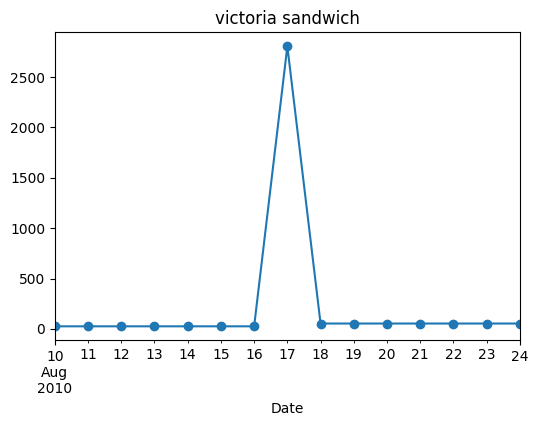

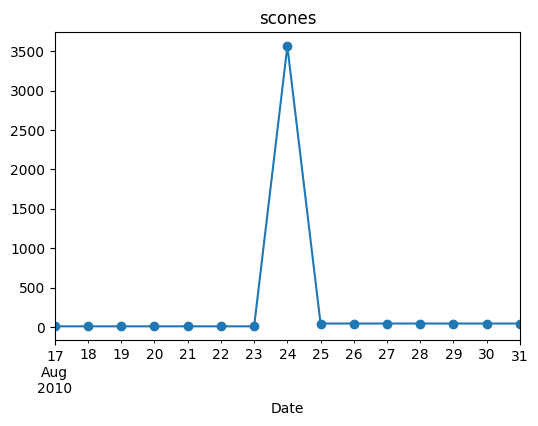

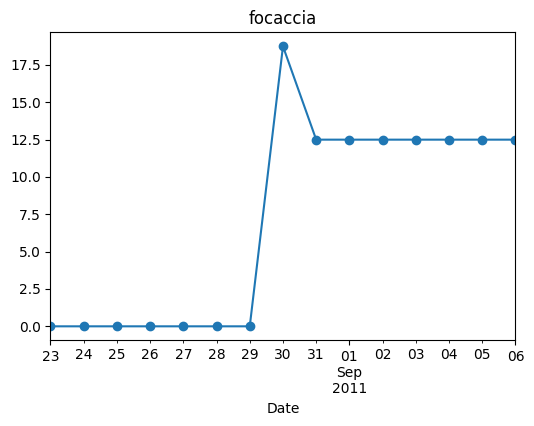

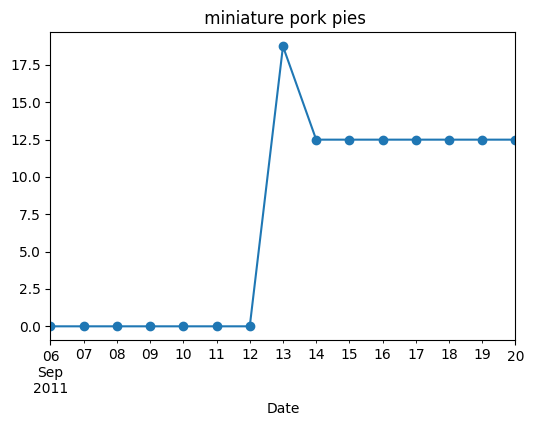

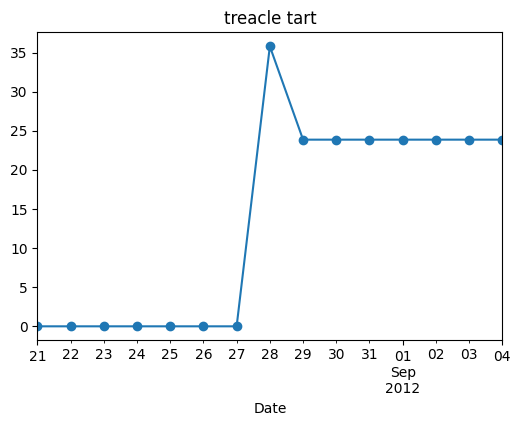

In [ ]:
#trying to visualize what these look like as linecharts

technicals_lift = bake_with_lifts['Technical'].to_list()

for bake in technicals_lift[:5]:
    row = bake_with_lifts[bake_with_lifts['Technical'] == bake].iloc[0]
    baseline = row['Baseline_Avg']

    post_air_avg = row['Post_Air_Avg']
    lift_pct = row['Lift_Pct']

    if baseline == 0 or np.isinf(lift_pct):
        spike_value = post_air_avg * 1.5
        clean_lift = (
            post_air_avg 
        )
    else:
        spike_value = baseline * (1 + lift_pct)
        clean_lift = lift_pct

    airdate = pd.to_datetime(row['Airdate'])
    date_range = pd.date_range(start=airdate - pd.Timedelta(days=30), end=airdate + pd.Timedelta(days=7))

    values = []
    for dt in date_range:
        if dt < airdate:
            values.append(baseline)
        elif dt == airdate:
            values.append(spike_value)
        else:
            values.append(post_air_avg)

    df_plot = pd.DataFrame(
        {
            "Date" : date_range,
            "Value": values
        }
    )

    fig, ax = plt.subplots(figsize=(6, 4))
    df_plot.plot(
        x="Date", y="Value", kind="line", marker="o", ax=ax, legend=False, title = bake
    )

In [90]:
#prepping bake_with_lifts for visualization

trend_data_for_linecharts = []
technicals_lift = bake_with_lifts['Technical'].to_list()

for bake in technicals_lift:
    row = bake_with_lifts[bake_with_lifts['Technical'] == bake].iloc[0]

    baseline = row['Baseline_Avg']
    post_air_avg = row['Post_Air_Avg']
    lift_pct = row['Lift_Pct']
    spike_value = post_air_avg * 1.5

    if baseline == 0 or np.isinf(lift_pct):
            lift_label = "New Interest"
    else:
        lift_label = f"{round(lift_pct)}%"
    

    airdate = pd.to_datetime(row['Airdate'])
    date_range = pd.date_range(start=airdate - pd.Timedelta(days=7), end=airdate + pd.Timedelta(days=7))

    for dt in date_range:
        day_offset = (dt - airdate).days

        if dt < airdate:
            val = baseline
            phase = "baseline"
        elif dt == airdate:
            val = spike_value
            phase = "spike"
        else:
            val = post_air_avg
            phase = "post_event_plateau"

        trend_data_for_linecharts.append(
            {
                "technical": bake,
                "date": dt.strftime("%Y-%m-%d"),
                "day_offset": day_offset,
                "value": round(val, 2),
                "phase": phase,
                "lift_pc": lift_label,
            }
        )

df_output = pd.DataFrame(trend_data_for_linecharts)
df_output.to_csv("trend_data_for_linecharts.csv", index=False)

<Axes: xlabel='Technical'>

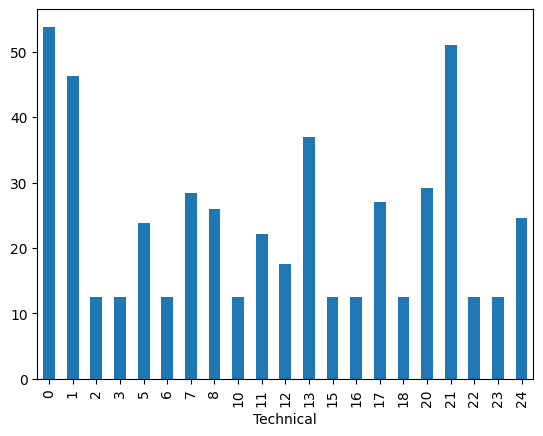

In [65]:
bake_with_lifts['Post_Air_Avg'].plot(kind='bar', x=bake_with_lifts['Technical'], xlabel='Technical')

In [ ]:
def trends_lift(df, tech, air_date):
    df = df.reset_index()
    df['days_since_air'] = (df['date'] - air_date).dt.days
    baseline = df[(df['days_since_air'] < 0)][tech].mean()
    post_air = df[(df['days_since_air'] >= 0) & (df['days_since_air'] <= 7)][tech].mean()
    return baseline, post_air